<a href="https://colab.research.google.com/github/aisyahfp/Metagenomic16s/blob/main/Rock_Paper_Scissor_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Klasifikasi Gambar
oleh Aisyah Fitriannisa Prawiningrum



In [ ]:
#cek versi tensorflow
import tensorflow as tf
print(tf.__version__)

2.3.0


In [ ]:
#download resource
!wget command: https://dicodingacademy.blob.core.windows.net/picodiploma/ml_pemula_academy/rockpaperscissors.zip

--2020-10-28 02:15:12--  ftp://command/
           => ‘.listing’
Resolving command (command)... failed: Name or service not known.
wget: unable to resolve host address ‘command’
--2020-10-28 02:15:12--  https://dicodingacademy.blob.core.windows.net/picodiploma/ml_pemula_academy/rockpaperscissors.zip
Resolving dicodingacademy.blob.core.windows.net (dicodingacademy.blob.core.windows.net)... 52.239.197.36
Connecting to dicodingacademy.blob.core.windows.net (dicodingacademy.blob.core.windows.net)|52.239.197.36|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 322873683 (308M) [application/zip]
Saving to: ‘rockpaperscissors.zip’

rockpaperscissors.z 100%[===================>] 307.92M  35.8MB/s    in 9.5s    

2020-10-28 02:15:22 (32.3 MB/s) - ‘rockpaperscissors.zip’ saved [322873683/322873683]

FINISHED --2020-10-28 02:15:22--
Total wall clock time: 9.9s
Downloaded: 1 files, 308M in 9.5s (32.3 MB/s)


In [ ]:
#ekstraksi zip file
import zipfile,os
local_zip = '/content/rockpaperscissors.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/content/images')
zip_ref.close()

In [ ]:
#install split-folders untuk membagi dataset
pip install split-folders tqdm

In [ ]:
#bagi dataset menjadi training:validation=60%:40%
import splitfolders
splitfolders.ratio('/content/images/rockpaperscissors/rps-cv-images', output='dataset', seed=1500, ratio=(.6, .4), group_prefix=None)

Copying files: 2188 files [00:00, 2946.95 files/s]


In [ ]:
#membuat variabel direktori
train_dir = '/content/dataset/train'
val_dir = '/content/dataset/val'

In [ ]:
#membuat imagedatagenerator untuk training dan validation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
                    rescale=1./255,
                    featurewise_center=True,
                    featurewise_std_normalization=True,
                    rotation_range=20,
                    vertical_flip=True,
                    shear_range = 0.2,
                    width_shift_range=0.2,
                    height_shift_range=0.2,
                    zoom_range=0.2,
                    fill_mode = 'nearest')

validation_datagen = ImageDataGenerator(
                    rescale=1./255,
                    featurewise_center=True,
                    featurewise_std_normalization=True,
                    rotation_range=20,
                    vertical_flip=True,
                    shear_range=0.2,
                    width_shift_range=0.2,
                    height_shift_range=0.2,
                    zoom_range=0.2,
                    fill_mode='nearest')

In [ ]:
#tensor image augmentation dari direktori target
train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(150, 100),
        batch_size=32,
        color_mode='rgb',
        class_mode='categorical')

validation_generator = validation_datagen.flow_from_directory(
        val_dir,
        target_size=(150, 100),
        batch_size=32,
        color_mode='rgb',
        class_mode='categorical')

Found 1312 images belonging to 3 classes.
Found 876 images belonging to 3 classes.


In [ ]:
#membangun model
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Activation, Dropout, Flatten, Dense
from keras.models import Sequential
from keras import Input

model = Sequential()
model.add(Input(shape=(150, 100, 3)))
model.add(Conv2D(32, 3, activation='relu'))
model.add(MaxPooling2D(3,2))
model.add(Conv2D(64, 3, activation='relu'))
model.add(MaxPooling2D(3,2))

#memastikan model
model.summary()

Model: "sequential_30"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_114 (Conv2D)          (None, 148, 98, 32)       896       
_________________________________________________________________
max_pooling2d_99 (MaxPooling (None, 73, 48, 32)        0         
_________________________________________________________________
conv2d_115 (Conv2D)          (None, 71, 46, 64)        18496     
_________________________________________________________________
max_pooling2d_100 (MaxPoolin (None, 35, 22, 64)        0         
Total params: 19,392
Trainable params: 19,392
Non-trainable params: 0
_________________________________________________________________


In [ ]:
#karena masih bisa di-downsampling lagi, akan layer akan ditambah
model.add(Conv2D(128, 3, activation='relu'))
model.add(MaxPooling2D(3,2))
model.add(Conv2D(256, 3, activation='relu'))
model.add(MaxPooling2D(3,2))

#cek model
model.summary()

Model: "sequential_30"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_114 (Conv2D)          (None, 148, 98, 32)       896       
_________________________________________________________________
max_pooling2d_99 (MaxPooling (None, 73, 48, 32)        0         
_________________________________________________________________
conv2d_115 (Conv2D)          (None, 71, 46, 64)        18496     
_________________________________________________________________
max_pooling2d_100 (MaxPoolin (None, 35, 22, 64)        0         
_________________________________________________________________
conv2d_116 (Conv2D)          (None, 33, 20, 128)       73856     
_________________________________________________________________
max_pooling2d_101 (MaxPoolin (None, 16, 9, 128)        0         
_________________________________________________________________
conv2d_117 (Conv2D)          (None, 14, 7, 256)      

In [ ]:
#downsampling dianggap sudah cukup, buat layer output
model.add(Flatten())
model.add(Dense(512,activation='relu'))
model.add(Dense(3,activation='softmax'))

#cek model
model.summary()

Model: "sequential_30"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_114 (Conv2D)          (None, 148, 98, 32)       896       
_________________________________________________________________
max_pooling2d_99 (MaxPooling (None, 73, 48, 32)        0         
_________________________________________________________________
conv2d_115 (Conv2D)          (None, 71, 46, 64)        18496     
_________________________________________________________________
max_pooling2d_100 (MaxPoolin (None, 35, 22, 64)        0         
_________________________________________________________________
conv2d_116 (Conv2D)          (None, 33, 20, 128)       73856     
_________________________________________________________________
max_pooling2d_101 (MaxPoolin (None, 16, 9, 128)        0         
_________________________________________________________________
conv2d_117 (Conv2D)          (None, 14, 7, 256)      

In [ ]:
#compile model, loss dan metrics menggunakan categorical karena kelasnyapun categorical
model.compile(loss='categorical_crossentropy',
              optimizer='rmsprop',
              metrics=['categorical_accuracy'])

In [ ]:
#training data yang di-generate train-generator
history = model.fit_generator(
      train_generator,
      steps_per_epoch=25,
      epochs=20,
      validation_data=validation_generator,
      validation_steps=5,
      verbose=2)

/usr/local/lib/python3.6/dist-packages/keras_preprocessing/image/image_data_generator.py:720: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn('This ImageDataGenerator specifies '
/usr/local/lib/python3.6/dist-packages/keras_preprocessing/image/image_data_generator.py:728: UserWarning: This ImageDataGenerator specifies `featurewise_std_normalization`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn('This ImageDataGenerator specifies '


Epoch 1/20
25/25 - 30s - loss: 1.1833 - categorical_accuracy: 0.3775 - val_loss: 2.3542 - val_categorical_accuracy: 0.3250
Epoch 2/20
25/25 - 29s - loss: 1.0961 - categorical_accuracy: 0.4688 - val_loss: 0.9230 - val_categorical_accuracy: 0.5000
Epoch 3/20
25/25 - 29s - loss: 0.7839 - categorical_accuracy: 0.6687 - val_loss: 0.7680 - val_categorical_accuracy: 0.6313
Epoch 4/20
25/25 - 29s - loss: 0.5598 - categorical_accuracy: 0.7625 - val_loss: 0.4191 - val_categorical_accuracy: 0.8125
Epoch 5/20
25/25 - 29s - loss: 0.4176 - categorical_accuracy: 0.8475 - val_loss: 0.2640 - val_categorical_accuracy: 0.9250
Epoch 6/20
25/25 - 29s - loss: 0.3306 - categorical_accuracy: 0.8950 - val_loss: 0.4272 - val_categorical_accuracy: 0.8438
Epoch 7/20
25/25 - 29s - loss: 0.2273 - categorical_accuracy: 0.9225 - val_loss: 0.1700 - val_categorical_accuracy: 0.9250
Epoch 8/20
25/25 - 29s - loss: 0.2730 - categorical_accuracy: 0.9150 - val_loss: 0.2095 - val_categorical_accuracy: 0.9250
Epoch 9/20
25/25

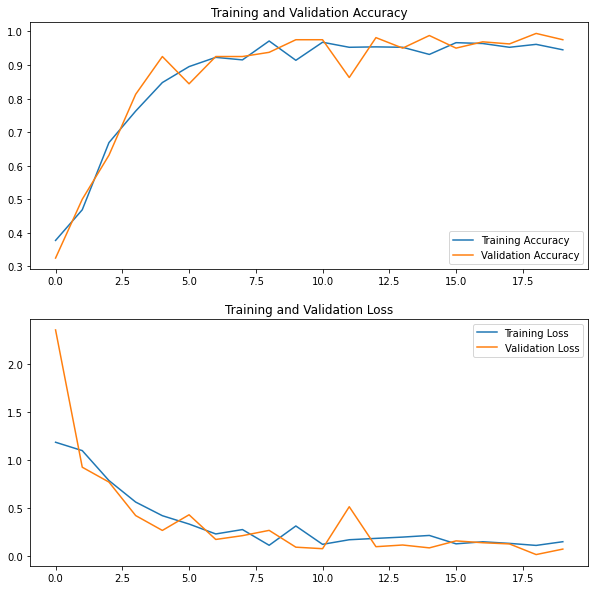

In [ ]:
#cek hasil training
import numpy as np
from google.colab import files
from keras.preprocessing import image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline

acc=history.history['categorical_accuracy']
val_acc=history.history['val_categorical_accuracy']

loss=history.history['loss']
val_loss=history.history['val_loss']

epochs_range=range(20)

plt.figure(figsize=(10,10))
plt.subplot(2,1,1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2,1,2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

Saving 20201028_120956.jpg to 20201028_120956.jpg
20201028_120956.jpg
paper


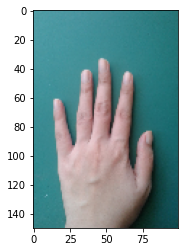

In [ ]:
#prediksi gambar
import numpy as np
from google.colab import files
from keras.preprocessing import image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline

uploaded = files.upload()

for fn in uploaded.keys():

  path = fn
  img = image.load_img(path, target_size=(150,100))
  imgplot = plt.imshow(img)
  x = image.img_to_array(img)
  x = np.expand_dims(x, axis=0)

  images = np.vstack([x])
  classes = model.predict(images, batch_size=10)

  print(fn)
  if classes[0,0]!=0:
    print('paper')
  elif classes[0,1]!=0:
    print('rock')
  else:
    print('scissors')